In [1]:
from collections import deque
import pickle
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from galaxy_dataset import get_dataloader
from VQ_VAE import construct_vae, optimizer, train

c:\Users\alexa\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Hyperparams

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_dim = 128
num_embeddings = 1024
commitment = 0.3
learning_rate = 5e-4
epochs = 100
batch_size = 128

### Read and Preprocess Dataset

In [3]:
image_folder = 'training_images'
image_size = (128, 128)

train_loader = get_dataloader(image_folder, image_size, batch_size, n=200000)

### Create VAE & Optimizer

In [4]:
vae = construct_vae(device, embedding_dim, num_embeddings, commitment)
optimizer = optimizer(vae, learning_rate)

#### Gathering Test Samples

In [13]:
seen_images = deque(maxlen=10)

for batch in train_loader:
    for img in batch:
        seen_images.append(img)
    break

seen_images = torch.stack(list(seen_images))

test_loader = get_dataloader(image_folder, image_size, batch_size, n=200100)

unseen_images = deque(maxlen=10)

i = 1
for batch in test_loader:
    if i < len(test_loader):
        i += 1
        continue
    for img in batch:
        unseen_images.append(img)

unseen_images = torch.stack(list(unseen_images))

### Train Model

In [ ]:
training_state_path = 'state.pkl'

try:
    with open(training_state_path, 'rb') as file:
        training_state_data = pickle.load(file)
    vae.load_state_dict(torch.load(f"vae_checkpoint_{training_state_data['last_epoch']}.pth", weights_only=True))
except:
    training_state_data = {
        'last_epoch': 0,
        'total_loss': [],
        'recon_loss': [],
        'codebook_loss': [],
        'codebook_usage': [],
    }

for epoch in range(training_state_data['last_epoch'] + 1, epochs + 1):
    avg_total_loss, avg_rec_loss, avg_vq_loss, used_indices = train(vae, device, train_loader, optimizer)
    
    print(f"\nEpoch [{epoch}/{epochs}]")
    print(f"Total Loss: {avg_total_loss:.4f}")
    print(f"Reconstruction Loss: {avg_rec_loss:.4f}")
    print(f"Codebook Loss: {avg_vq_loss:.4f}")
    print(f"Used {100 * used_indices / vae.vq.num_embeddings:.2f}% codebook entries\n")
    
    recon, *_ = vae(seen_images.to(device))
    comparison = torch.cat([seen_images, recon.cpu()])
    vutils.save_image(comparison, f'recon_epoch_{epoch}.png', nrow=8, normalize=True)
    
    training_state_data['last_epoch'] = epoch
    training_state_data['total_loss'].append(avg_total_loss)
    training_state_data['recon_loss'].append(avg_rec_loss)
    training_state_data['codebook_loss'].append(avg_vq_loss)
    training_state_data['codebook_usage'].append(used_indices / vae.vq.num_embeddings)
    
    torch.save(vae.state_dict(), f"vae_checkpoint_{epoch}.pth")
    pickle.dump(training_state_data, path)

KeyboardInterrupt: 

### Image Reconstruction

#### Reconstructing Images

In [ ]:
seen_reconstructions, *_ = vae(seen_images)
unseen_reconstructions, *_ = vae(unseen_images)

seen_images = seen_images.permute(0, 2, 3, 1)
unseen_images = unseen_images.permute(0, 2, 3, 1)

seen_reconstructions = seen_reconstructions.permute(0, 2, 3, 1).detach().numpy()
unseen_reconstructions = unseen_reconstructions.permute(0, 2, 3, 1).detach().numpy()

#### Seen Images

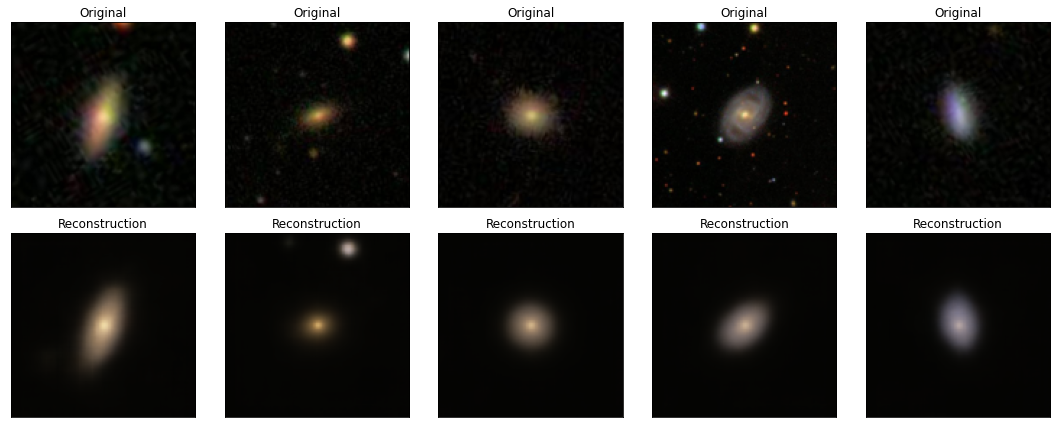

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), facecolor='white')

for i in range(5):
    ax[0][i].set_title('Original')
    ax[0][i].imshow(seen_images[i])
    ax[1][i].set_title('Reconstruction')
    ax[1][i].imshow(seen_reconstructions[i])

for row in ax:
    for figure in row:
        figure.set_xticks([])
        figure.set_yticks([])

fig.tight_layout()

#### Unseen Images

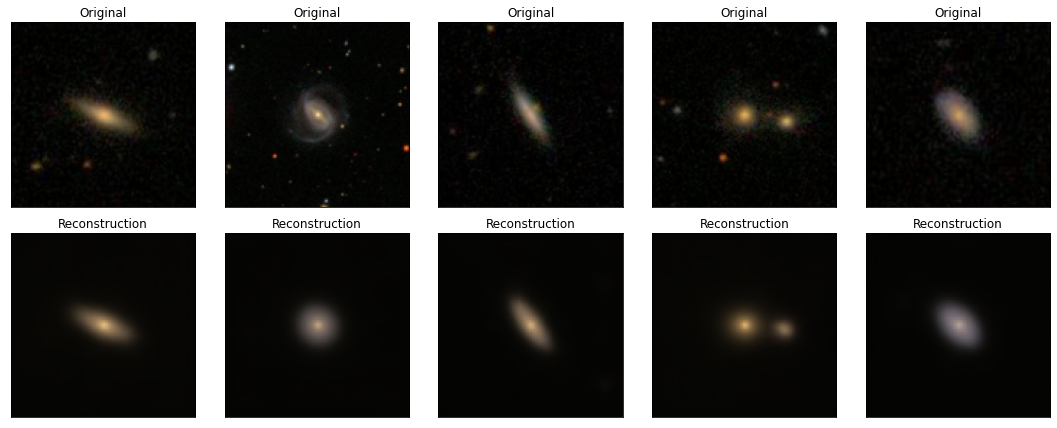

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), facecolor='white')

for i in range(5):
    ax[0][i].set_title('Original')
    ax[0][i].imshow(unseen_images[i])
    ax[1][i].set_title('Reconstruction')
    ax[1][i].imshow(unseen_reconstructions[i])

for row in ax:
    for figure in row:
        figure.set_xticks([])
        figure.set_yticks([])

fig.tight_layout()